## Exercício prático — Dia 02
Complete os passos no notebook usando a base `base_rh.xlsx` e crie os gráficos finais pedindo ao gerente de produção.

1. Carregue `base_rh.xlsx` com `pd.read_excel(URL)` e converta `Data_Admissao` para datetime. Crie `Ano_Admissao` com `.dt.year`.
2. Use `groupby(["Departamento", "Cargo"])` para contar funcionários e exiba o resultado.
3. Use `groupby("Ano_Admissao")` para contar admissões por ano e filtre 2020–2024 com `query()`.
4. Crie uma tabela de metas de headcount por departamento com `pd.DataFrame` e faça `merge left` com o total por departamento. Identifique se a meta foi atingida.
5. Crie um `pivot_table` de `Salario` médio por `Departamento` e `Genero`. Calcule a diferença `F - M`.
6. Plote admissões por ano com `plt.plot(..., marker="o")`.
7. Plote o `pivot_table` de salário médio por gênero com `pivot.plot(kind="bar")`.
8. Faça commit com mensagem `semana 05 - dia 02: groupby, merge, pivot_table, graficos`.


---
### Passo 1 — Setup: carregar dados e preparar colunas


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# URL da planilha que usamos nesta aula
URL = (
    "https://raw.githubusercontent.com/"
    "cfneves/turma-visualizacao-de-dados/"
    "master/alunos/orlando_castro/semana_04/bases/base_rh.xlsx"
)

# Lê o arquivo Excel diretamente da internet
df = pd.read_excel(URL)

# Converte a coluna de data de admissão para o tipo datetime
df["Data_Admissao"] = pd.to_datetime(
    df["Data_Admissao"],
    format="%d/%m/%Y",
    errors="coerce"
)

# Mostra quantas linhas e colunas temos e os tipos de cada coluna
print(f"Dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(df.dtypes)

Dataset: 1000 linhas x 10 colunas
ID_Funcionario             int64
Nome                      object
Departamento              object
Cargo                     object
Salario                  float64
Data_Admissao     datetime64[ns]
Genero                    object
Idade                      int64
Estado_Civil              object
Status                    object
dtype: object


---
### Passo 2 - groupby de Departamento × Cargo


In [9]:
headcount_cargo = (
    df.groupby(["Departamento", "Cargo"])["ID_Funcionario"]         # agrupa por departamento e cargo, contando o número de funcionários em cada combinação
    .count()                                                        # conta o número de funcionários (ID_Funcionario) para cada grupo
    .reset_index()                                                  # reseta o índice para transformar o resultado em um DataFrame normal
    .rename(columns={"ID_Funcionario": "Quantidade"})               # renomeia a coluna de contagem para "Quantidade"
    .sort_values(["Departamento", "Quantidade"], ascending=[True, False]) # ordena os resultados primeiro por departamento em ordem alfabética e depois por quantidade em ordem decrescente, para mostrar os cargos mais comuns em cada departamento no topo
)

print(f"Total de combinações Departamento × Cargo: {len(headcount_cargo)}")
print()
print(headcount_cargo.to_string(index=False))

Total de combinações Departamento × Cargo: 30

Departamento       Cargo  Quantidade
  Financeiro     Gerente          44
  Financeiro    Analista          40
  Financeiro     Técnico          38
  Financeiro Coordenador          37
  Financeiro  Assistente          30
   Logística  Assistente          38
   Logística Coordenador          38
   Logística     Gerente          33
   Logística    Analista          29
   Logística     Técnico          18
    Produção     Gerente          43
    Produção  Assistente          41
    Produção Coordenador          40
    Produção     Técnico          36
    Produção    Analista          22
          RH Coordenador          44
          RH  Assistente          35
          RH    Analista          32
          RH     Gerente          30
          RH     Técnico          25
          TI     Técnico          32
          TI    Analista          31
          TI     Gerente          31
          TI Coordenador          28
          TI  Assistente    

---
### Passo 3 — Admissões por ano com filtro 2020–2024

**Dica do Professor:**

**Por que `query()` aqui?**
O `query()` é mais legível que `df[(df["Ano"] >= 2020) & (df["Ano"] <= 2024)]` — especialmente quando a condição envolve um intervalo. Funciona direto no resultado do groupby depois do `reset_index()`, porque a coluna `Ano_Admissao` já está disponível como coluna normal.

**Armadilha comum:** fazer o `query()` antes do `reset_index()` gera `KeyError` porque a coluna ainda é o índice, não uma coluna acessível pelo nome.

In [ ]:
# Extrai o ano da data de admissão para poder agrupar por ano
df["Ano_Admissao"] = df["Data_Admissao"].dt.year

admissoes = (
    df.groupby("Ano_Admissao")["ID_Funcionario"]            # agrupa por ano de admissão, contando o número de funcionários admitidos em cada ano
    .count()                                                # conta o número de funcionários (ID_Funcionario) para cada ano de admissão     
    .reset_index()                                          # Ano_Admissao vira coluna
    .rename(columns={"ID_Funcionario": "Admissoes"})        # renomeia a coluna de contagem para "Admissoes"
    .query("Ano_Admissao >= 2020 and Ano_Admissao <= 2024") # filtra após reset
    .sort_values("Ano_Admissao")                            # ordena por ano de admissão em ordem crescente
)

print("Admissões por ano (2020–2024):")
print(admissoes.to_string(index=False))
print(f"\nTotal de admissões no período: {admissoes['Admissoes'].sum()}")

Admissões por ano (2020–2024):
 Ano_Admissao  Admissoes
         2020         94
         2021         94
         2022        108
         2023        106
         2024        113

Total de admissões no período: 515


---
### Passo 4 — Tabela de metas + merge left


In [12]:
# ── Headcount real por departamento ─────────────────────────────────────
headcount_real = (
    df.groupby("Departamento")          # agrupa por departamento
    .size()                             # conta o número de funcionários em cada departamento
    .reset_index(name="Total_Real")     # reseta o índice e renomeia a coluna
    .sort_values("Departamento")        # ordena por departamento
)

print("Headcount real por departamento:")
print(headcount_real.to_string(index=False))

# ── Cria Tabela de metas de headcount para cada departamento ───────────────────────────────
metas_headcount = pd.DataFrame({
    "Departamento": ["Financeiro", "Logística", "Manutenção",
                     "Produção", "RH", "TI", "Vendas"],
    "Meta_Headcount": [135, 130, 125, 185, 165, 135, 125]
})

print("\nTabela de metas:")
print(metas_headcount.to_string(index=False))

# ── Merge left: mantém todos os departamentos do headcount real ───────────
comparacao_hc = pd.merge(
    headcount_real,
    metas_headcount,
    on="Departamento",
    how="left"
)

# Identifica se a meta foi atingida
comparacao_hc["Diferenca"]    = comparacao_hc["Total_Real"] - comparacao_hc["Meta_Headcount"]
comparacao_hc["Atingiu_Meta"] = comparacao_hc["Diferenca"].apply(
    lambda x: "✅ Sim" if x >= 0 else "❌ Não"
)

print("\nComparação real vs meta:")
print(comparacao_hc.to_string(index=False))

Headcount real por departamento:
Departamento  Total_Real
  Financeiro         189
   Logística         156
    Produção         182
          RH         166
          TI         147
      Vendas         160

Tabela de metas:
Departamento  Meta_Headcount
  Financeiro             135
   Logística             130
  Manutenção             125
    Produção             185
          RH             165
          TI             135
      Vendas             125

Comparação real vs meta:
Departamento  Total_Real  Meta_Headcount  Diferenca Atingiu_Meta
  Financeiro         189             135         54        ✅ Sim
   Logística         156             130         26        ✅ Sim
    Produção         182             185         -3        ❌ Não
          RH         166             165          1        ✅ Sim
          TI         147             135         12        ✅ Sim
      Vendas         160             125         35        ✅ Sim


---
### Passo 5 — pivot_table: salário médio por Departamento × Gênero


In [13]:
pivot_genero = pd.pivot_table(            # cria uma tabela cruzada de salário médio por departamento e gênero
    df,                                   # DataFrame original
    values   = "Salario",                 # coluna de valores que queremos agregar
    index    = "Departamento",            # coluna que queremos usar como índice (linhas)
    columns  = "Genero",                  # coluna que queremos usar para criar as colunas da tabela cruzada
    aggfunc  = "mean",                    # função de agregação para calcular a média salarial para cada combinação de departamento e gênero
    fill_value = 0                        # preenche com zero as combinações de departamento e gênero que não existem no DataFrame original
).round(2)

# Diferença salarial: F - M (positivo = mulheres ganham mais)
pivot_genero["Diferenca_F_M"] = (pivot_genero["F"] - pivot_genero["M"]).round(2) # nova coluna que mostra a diferença salarial entre mulheres e homens, arredondada para 2 casas decimais

print("Salário médio por Departamento e Gênero:")
print(pivot_genero.to_string())

print(f"\nResumo da diferença salarial F - M:")
print(f"  Maior gap a favor de F : {pivot_genero['Diferenca_F_M'].max():+,.2f}  "
      f"({pivot_genero['Diferenca_F_M'].idxmax()})")
print(f"  Maior gap a favor de M : {pivot_genero['Diferenca_F_M'].min():+,.2f}  "
      f"({pivot_genero['Diferenca_F_M'].idxmin()})")
print(f"  Diferença média geral  : {pivot_genero['Diferenca_F_M'].mean():+,.2f}")

Salário médio por Departamento e Gênero:
Genero              F        M  Diferenca_F_M
Departamento                                 
Financeiro    8467.26  8208.56         258.70
Logística     8843.49  8944.41        -100.92
Produção      8797.64  9118.66        -321.02
RH            9009.20  8546.06         463.14
TI            8107.01  8177.38         -70.37
Vendas        8926.64  7751.59        1175.05

Resumo da diferença salarial F - M:
  Maior gap a favor de F : +1,175.05  (Vendas)
  Maior gap a favor de M : -321.02  (Produção)
  Diferença média geral  : +234.10


---
### Passo 6 — Gráfico de linha: admissões por ano (2020–2024)


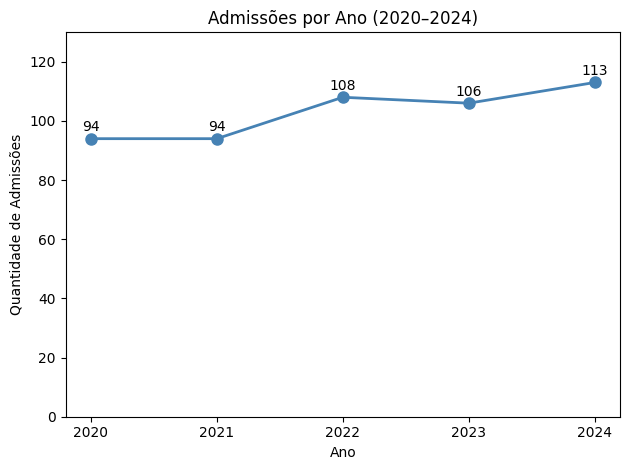

In [15]:
plt.plot(
    admissoes["Ano_Admissao"],
    admissoes["Admissoes"],
    marker="o",
    color="steelblue",
    linewidth=2,
    markersize=8
)

# Rótulo com o valor em cima de cada ponto
for _, row in admissoes.iterrows():
    plt.text(row["Ano_Admissao"], row["Admissoes"] + 1.5,
             str(int(row["Admissoes"])),
             ha="center", va="bottom", fontsize=10)

plt.title("Admissões por Ano (2020–2024)")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Admissões")
plt.xticks(admissoes["Ano_Admissao"].astype(int))
plt.ylim(0, admissoes["Admissoes"].max() * 1.15)
plt.tight_layout()
plt.show()

---
### Passo 7 — Gráfico de barras agrupadas: salário médio por gênero


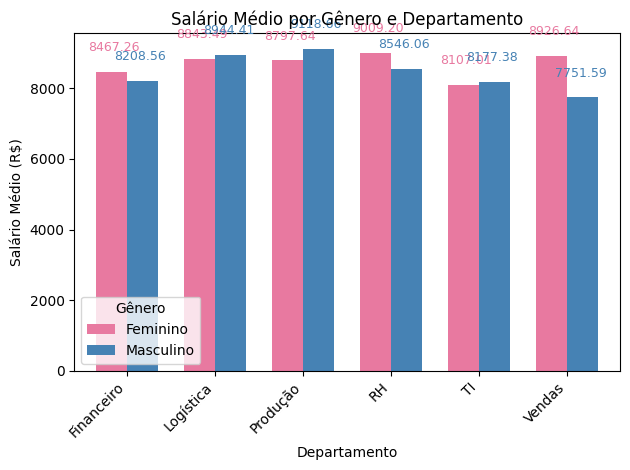

In [16]:
pivot_genero[["F", "M"]].plot(
    kind="bar",
    color=["#e879a0", "steelblue"],
    width=0.7
)

plt.title("Salário Médio por Gênero e Departamento")
plt.xlabel("Departamento")
plt.ylabel("Salário Médio (R$)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gênero", labels=["Feminino", "Masculino"])
plt.tight_layout()
# Exibe rótulos
for i, (f, m) in enumerate(zip(pivot_genero["F"], pivot_genero["M"])):
    plt.text(i - 0.15, f + 500, f"{f:.2f}", ha="center", va="bottom", fontsize=9, color="#e879a0")
    plt.text(i + 0.15, m + 500, f"{m:.2f}", ha="center", va="bottom", fontsize=9, color="steelblue")

plt.show()